# Quick start

This guide demonstrates a minimal working example of the `qiskit-paulice` package. We use [spacetime Pauli checks](https://arxiv.org/abs/2504.15725) to detect errors during execution of a Clifford circuit, then postselect only samples for which no error was detected. For a more explanatory end-to-end workflow that quantifies the fidelity improvement, see the [qiskit-paulice tutorial](https://github.com/Qiskit/qiskit-paulice/blob/main/docs/tutorials/01_low_overhead_error_detection_using_spacetime_codes.ipynb).

**Workflow steps**
1. Build a Clifford payload circuit and choose physical qubits on which to implement it.
2. Select ancilla qubits adjacent to the payload qubits. Pauli checks will be implemented by entangling these ancillas to the payload.
3. Generate a rough noise model that models the gate and readout noise on the target backend (``ibm_boston``).
4. Find good spacetime Pauli checks and add them to the circuit.
5. Sample the checked circuit
6. Postselect only samples for which no error was detected.

## 1. Build a payload circuit and choose physical qubits

The input to `qiskit-paulice` is a Clifford circuit terminated with at least one measurement. We use a shallow brickwork random Clifford circuit on 12 qubits and map it onto a 1D `layout` of physical qubits on the Heron r3 QPU `ibm_boston`.

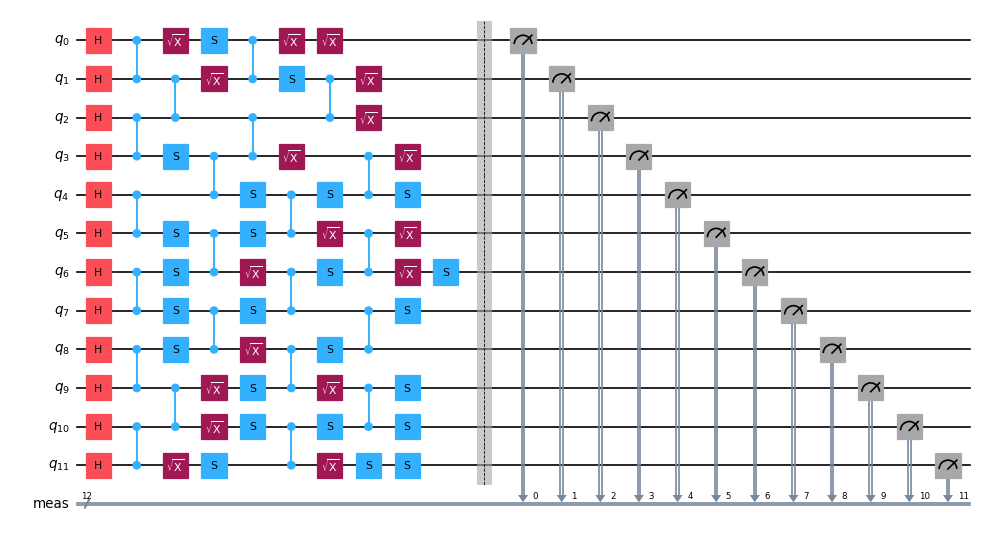

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService

# Choose a backend and a 1D layout of physical qubits
backend = QiskitRuntimeService().backend("ibm_boston")
layout = [68, 69, 78, 89, 90, 91, 98, 111, 112, 113, 119, 133]

# Build a shallow brickwork random Clifford payload circuit
rng = np.random.default_rng(1764)
circuit = QuantumCircuit(len(layout))
circuit.h(range(circuit.num_qubits))
for d in range(4):
    for i in range(d % 2, circuit.num_qubits - 1, 2):
        circuit.cz(i, i + 1)
    for q in range(circuit.num_qubits):
        if rng.integers(0, 2):
            circuit.sx(q)
        if rng.integers(0, 2):
            circuit.s(q)
circuit.measure_all()
circuit.draw("mpl", scale=0.6, fold=-1)

## 2. Select ancilla qubits adjacent to the payload

`get_low_overhead_ancillas` returns a mapping from each qubit neighboring the layout to the payload qubits it is adjacent to. We pair one payload qubit with each ancilla to build equal-length `target_qubits` and `ancilla_qubits` lists. A check on `target_qubits[i]` is entangled with `ancilla_qubits[i]`, which requires no SWAP gates because the two qubits are already adjacent.

In [2]:
from qiskit_paulice.layout import get_low_overhead_ancillas

ancillas_to_payload = get_low_overhead_ancillas(backend.coupling_map, layout)

target_qubits, ancilla_qubits = [], []
for ancilla_id, payload_ids in ancillas_to_payload.items():
    for q in payload_ids:
        if q not in target_qubits:
            target_qubits.append(int(q))
            ancilla_qubits.append(int(ancilla_id))
            break

print(f"target qubits:  {target_qubits}")
print(f"ancilla qubits: {ancilla_qubits}")

target qubits:  [68, 69, 89, 91, 111, 113, 133]
ancilla qubits: [67, 70, 88, 92, 110, 114, 134]


## 3. Generate a noise model

``qiskit_paulice.add_pauli_checks`` scores candidate checks against a noise model such that checks are placed where they capture the most error. A learned Pauli-Lindblad model can be supplied via `NoiseModel.from_pauli_lindblad_maps`, but a uniform depolarizing model inferred from backend benchmark data is usually sufficient.

In [3]:
from qiskit_paulice.noise_models import NoiseModel

noise_model = NoiseModel.from_backend(backend, layout, uniform_gate_noise=True)
print(noise_model)

NoiseModel(gate_noise=0.0017561251226655796, readout_noise=0.004648844401041667, idling_noise=None)


## 4. Find and add spacetime Pauli checks

We call `add_pauli_checks` on the virtual circuit, passing the targets as virtual indices. Checks are found and committed to each target in the order given: once a check is set on `target_qubits_v[0]`, the search moves on to `target_qubits_v[1]`, and so on. Each ancilla is added to a new `checks_q` register.

The function returns a sequence of ``CheckedCircuit`` instances with increasing numbers of checks, from no checks up to one per target qubit. Each added check improves error detection at the cost of some depth, so it is worth choosing a number of checks that provide maximal error detection with minimal increase in circuit depth; here we choose the checked circuit containing one check on each target qubit.

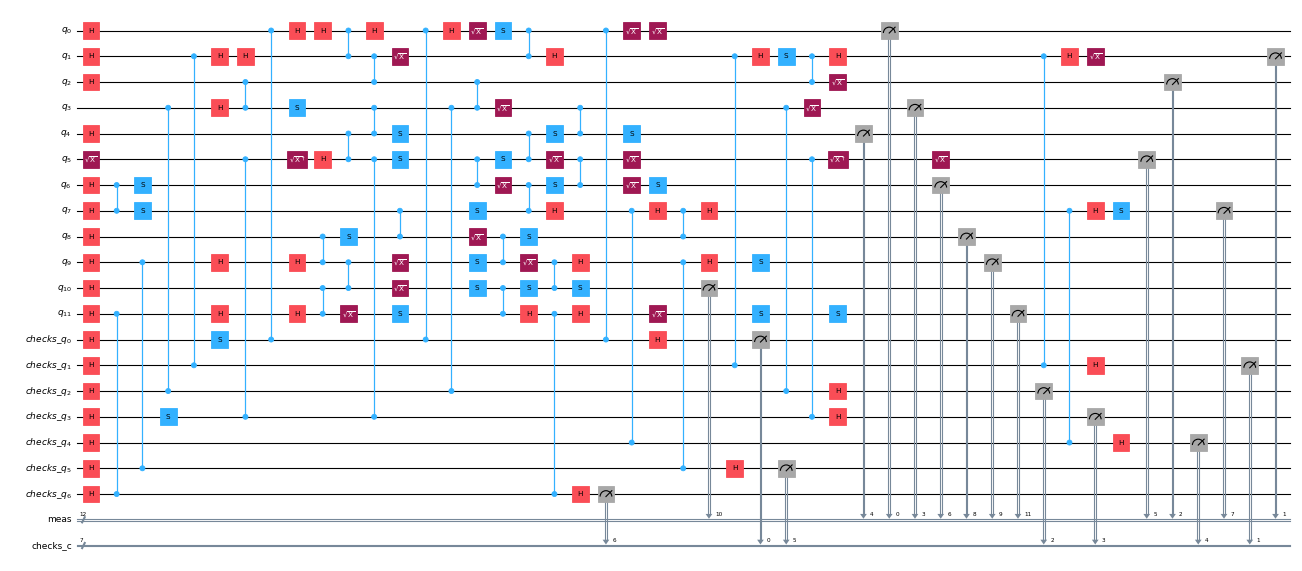

In [4]:
from qiskit_paulice import add_pauli_checks

target_qubits_v = [layout.index(q) for q in target_qubits]  # virtual (in-circuit) indices
checked_circuit = add_pauli_checks(circuit, target_qubits_v, noise_model)[-1]
checked_circuit.circuit.draw("mpl", fold=-1, scale=0.4, idle_wires=False)

## 5. Sample the checked circuit

Before sampling, we transpile the checked circuit with respect to the backend physical qubit topology and basis gate set. The ``initial_layout`` can be determined by concatenating the layout and ancilla qubits: ``initial_layout = layout + ancilla_qubits``. Because each check uses a neighboring ancilla, no SWAP gates are needed. To simulate a noisy QPU, we sample using a noisy Aer stabilizer backend whose `cz` depolarizing error and readout error match the `noise_model` we used to pick checks.

In [5]:
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel as AerNoiseModel
from qiskit_aer.noise import ReadoutError, depolarizing_error

# Transpile once: lay the checked circuit out on our qubits and into the native basis
isa_circuit = transpile(
    checked_circuit.circuit, backend, initial_layout=layout + ancilla_qubits, optimization_level=0
)

# Build an Aer noise model matching the depolarizing model used to pick checks
aer_noise = AerNoiseModel()
aer_noise.add_all_qubit_quantum_error(depolarizing_error(noise_model.gate_noise, 2), ["cz"])
p = noise_model.readout_noise
aer_noise.add_all_qubit_readout_error(ReadoutError([[1 - p, p], [p, 1 - p]]))
simulator = AerSimulator(method="stabilizer", noise_model=aer_noise)

counts = simulator.run(isa_circuit, shots=1000, seed_simulator=1764).result().get_counts()
print(f"sampled {sum(counts.values())} shots")

sampled 1000 shots


## 6. Postselect samples with no detected error

Each `CheckedCircuit` exposes `get_postselection_method`, which returns a function mapping a single shot to its syndrome vector. We keep only the shots whose syndrome is entirely zero — those in which no check detected an error. We observe that the surviving distribution is closer to the noiseless ideal.

In [6]:
from qiskit.quantum_info import hellinger_fidelity
from qiskit.result import marginal_distribution

# Keep only the shots in which no check reported an error
ps_fn = checked_circuit.get_postselection_method()
counts_postselected = {bs: n for bs, n in counts.items() if not ps_fn(bs).any()}

kept, total = sum(counts_postselected.values()), sum(counts.values())
print(f"kept {kept} of {total} shots ({kept / total:.0%})")


# Compare the payload distribution against a noiseless reference
def pay(c):
    return marginal_distribution(c, list(range(circuit.num_qubits)))


ideal = (
    AerSimulator(method="stabilizer")
    .run(isa_circuit, shots=10_000, seed_simulator=1764)
    .result()
    .get_counts()
)
print(
    f"fidelity  noisy {hellinger_fidelity(pay(counts), pay(ideal)):.3f} | "
    f"postselected {hellinger_fidelity(pay(counts_postselected), pay(ideal)):.3f}"
)

kept 900 of 1000 shots (90%)
fidelity  noisy 0.729 | postselected 0.750
